In [ ]:
!pip install ultralytics roboflow opencv-python matplotlib pandas seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 139.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.1
    Uninstalling typer-0.27.1:
      Successfully uninstalled typer-0.27.1


In [ ]:
#Importing libraries for DL and ImageProcessing
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
import torch
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2

# Dataset path in Google Drive
dataset_path = "/content/drive/MyDrive/Dataset"

# Paths
train_img_path = os.path.join(dataset_path, "train", "images")
train_lbl_path = os.path.join(dataset_path, "train", "labels")

val_img_path = os.path.join(dataset_path, "valid", "images")
val_lbl_path = os.path.join(dataset_path, "valid", "labels")

test_img_path = os.path.join(dataset_path, "test", "images")
test_lbl_path = os.path.join(dataset_path, "test", "labels")

# Count files
print(f"Training images: {len(os.listdir(train_img_path))}")
print(f"Training labels: {len(os.listdir(train_lbl_path))}")

print(f"Validation images: {len(os.listdir(val_img_path))}")
print(f"Validation labels: {len(os.listdir(val_lbl_path))}")

print(f"Test images: {len(os.listdir(test_img_path))}")
print(f"Test labels: {len(os.listdir(test_lbl_path))}")

# Load a sample image
sample_img = os.listdir(train_img_path)[0]
sample_img_path = os.path.join(train_img_path, sample_img)

img = cv2.imread(sample_img_path)

print(f"\nSample image: {sample_img}")
print(f"Sample image shape: {img.shape}")

# Class names
class_names = ["Fire", "Smoke"]
print(f"Class names: {class_names}")

Training images: 597
Training labels: 597
Validation images: 173
Validation labels: 173
Test images: 85
Test labels: 85

Sample image: image_166_jpg.rf.b49d49f1dd4f4fa6cf24df5993e36349.jpg
Sample image shape: (416, 416, 3)
Class names: ['Fire', 'Smoke']


In [ ]:
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
  tf.config.experimental.set_memory_growth(physical_devices[0],True)
  print('GPU is Available')
else:
  print('GPU Unavailable')

GPU is Available


In [ ]:
import yaml

data_yaml = {
    'train': '/content/drive/MyDrive/Dataset/train/images',
    'val': '/content/drive/MyDrive/Dataset/valid/images',
    'test': '/content/drive/MyDrive/Dataset/test/images',
    'nc': 2,
    'names': ['Fire', 'Smoke']
}

# Save data.yaml in Colab
yaml_path = '/content/data.yaml'

with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("data.yaml created successfully!")
print("\nContent:")

with open(yaml_path, 'r') as f:
    print(f.read())

data.yaml created successfully!

Content:
names:
- Fire
- Smoke
nc: 2
test: /content/drive/MyDrive/Dataset/test/images
train: /content/drive/MyDrive/Dataset/train/images
val: /content/drive/MyDrive/Dataset/valid/images



Image: image_119_jpg.rf.abde85a770b155189f411b57fbcd949b.jpg
Label: image_119_jpg.rf.abde85a770b155189f411b57fbcd949b.txt


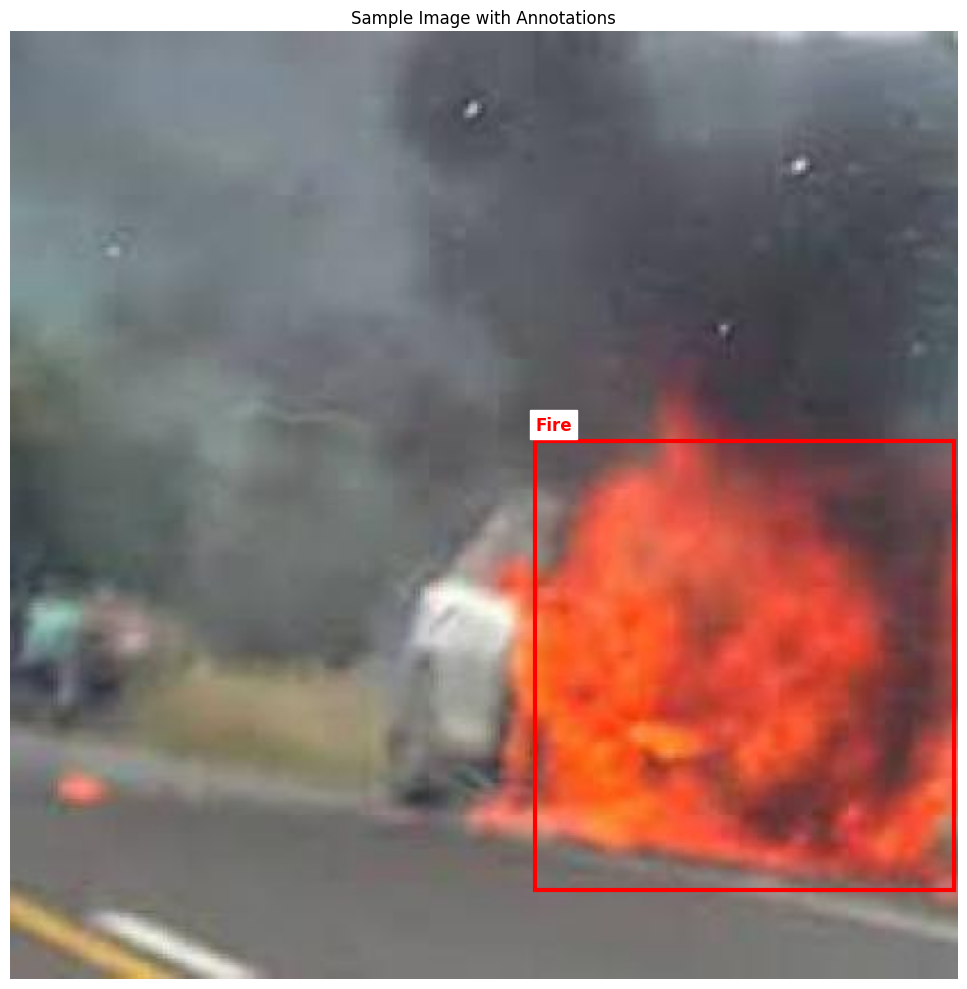

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def visualize_annotations(img_path, label_path, class_names=['Fire', 'Smoke']):
    # Load image
    img = cv2.imread(img_path)

    if img is None:
        print(f"Could not load image: {img_path}")
        return

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    # Plot image
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(img)

    # Read YOLO annotation file
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()

            if len(parts) >= 5:
                cls_id = int(parts[0])

                # YOLO normalized coordinates → pixel coordinates
                x_center = float(parts[1]) * w
                y_center = float(parts[2]) * h
                box_w = float(parts[3]) * w
                box_h = float(parts[4]) * h

                # Convert center coordinates to top-left coordinates
                x = x_center - box_w / 2
                y = y_center - box_h / 2

                # Different colors for Fire and Smoke
                color = 'red' if cls_id == 0 else 'orange'

                # Draw bounding box
                rect = Rectangle(
                    (x, y),
                    box_w,
                    box_h,
                    linewidth=3,
                    edgecolor=color,
                    facecolor='none'
                )

                ax.add_patch(rect)

                # Add class label
                ax.text(
                    x,
                    max(y - 5, 5),
                    class_names[cls_id],
                    color=color,
                    fontsize=12,
                    weight='bold',
                    backgroundcolor='white'
                )

    ax.set_title("Sample Image with Annotations")
    ax.axis('off')
    plt.tight_layout()
    plt.show()


# Get sample image
image_files = [
    f for f in os.listdir(train_img_path)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

sample_img = image_files[2]

# Get corresponding label file
sample_label = os.path.splitext(sample_img)[0] + '.txt'

image_path = os.path.join(train_img_path, sample_img)
label_path = os.path.join(train_lbl_path, sample_label)

print(f"Image: {sample_img}")
print(f"Label: {sample_label}")

# Visualize
if os.path.exists(label_path):
    visualize_annotations(image_path, label_path)
else:
    print(f"Label file not found for {sample_img}")

Training Configuration

In [ ]:
MODEL_SIZE = 'm'
EPOCHS = 150
BATCH_SIZE = 16
IMG_SIZE = 640
DEVICE = 0 if torch.cuda.is_available() else 'cpu'
WORKERS = 4
PATIENCE = 45
PROJECT_NAME = 'fire_smoke_detector'
EXPERIMENT_NAME = 'experiment_v2'

print(f"Configuration:")
print(f"Model Size: YOLOv8{MODEL_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Image Size: {IMG_SIZE}")
print(f"Device: {DEVICE}")
print(f"Patience: {PATIENCE}")

Configuration:
Model Size: YOLOv8m
Epochs: 150
Batch Size: 16
Image Size: 640
Device: 0
Patience: 45


In [ ]:
model = YOLO(f'yolov8{MODEL_SIZE}.pt')

results = model.train(
    data='/content/data.yaml',
    epochs=EPOCHS,
    batch=BATCH_SIZE,
    imgsz=IMG_SIZE,
    device=DEVICE,
    workers=WORKERS,
    patience=PATIENCE,
    project=PROJECT_NAME,
    name=EXPERIMENT_NAME,
    exist_ok=True,
    pretrained=True,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    box=7.5,
    cls=0.5,
    dfl=1.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=0.0,
    translate=0.1,
    scale=0.7,          # increased from 0.5 — more scale variation helps diffuse/varying-size smoke
    shear=0.0,
    perspective=0.0005,  # added — smoke has no fixed viewing angle
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.1,           # added — helps model learn soft/translucent smoke boundaries
    copy_paste=0.0
)

print("Training completed successfully!")

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=experiment_v2, nbs=64, nms=False, opset=No

Evaluating model performance

In [ ]:
from ultralytics import YOLO
import torch

# Correct Colab path
best_model_path = f'/content/runs/detect/{PROJECT_NAME}/{EXPERIMENT_NAME}/weights/best.pt'

# Load best model
model = YOLO(best_model_path)

print(f"Model loaded from: {best_model_path}")

# Validate on validation set
metrics = model.val(
    data='/content/data.yaml',
    device=DEVICE
)

print("\n EVALUATION METRICS ")

print(f"mAP@0.5:       {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95:  {metrics.box.map:.4f}")
print(f"Precision (P): {metrics.box.mp:.4f}")
print(f"Recall (R):    {metrics.box.mr:.4f}")

# F1 Score
if metrics.box.mp > 0 and metrics.box.mr > 0:
    f1 = 2 * (metrics.box.mp * metrics.box.mr) / (
        metrics.box.mp + metrics.box.mr + 1e-6
    )
    print(f"F1 Score:      {f1:.4f}")
print ("Class-Wise ")
# Class-wise mAP@0.5:0.95

print("mAP@0.5:0.95")

class_names = ['Fire', 'Smoke']

if hasattr(metrics.box, 'maps'):
    for i, class_name in enumerate(class_names):
        if i < len(metrics.box.maps):
            print(f"{class_name}: {metrics.box.maps[i]:.4f}")

# Class-wise mAP@0.5

print("mAP@0.5")

if hasattr(metrics.box, 'ap50'):
    for i, class_name in enumerate(class_names):
        if i < len(metrics.box.ap50):
            print(f"{class_name}: {metrics.box.ap50[i]:.4f}")
else:
    print("Class-wise AP50 not available.")


ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
import pandas as pd

results_file = '/content/runs/detect/fire_smoke_detector/experiment_v3/results.csv'

df = pd.read_csv(results_file)

print("Number of epochs:", len(df))
print("Last epoch:", df['epoch'].iloc[-1])

best_idx = df['metrics/mAP50(B)'].idxmax()

print("Best epoch:", int(df.loc[best_idx, 'epoch']))
print("Best mAP@0.5:", df.loc[best_idx, 'metrics/mAP50(B)'])

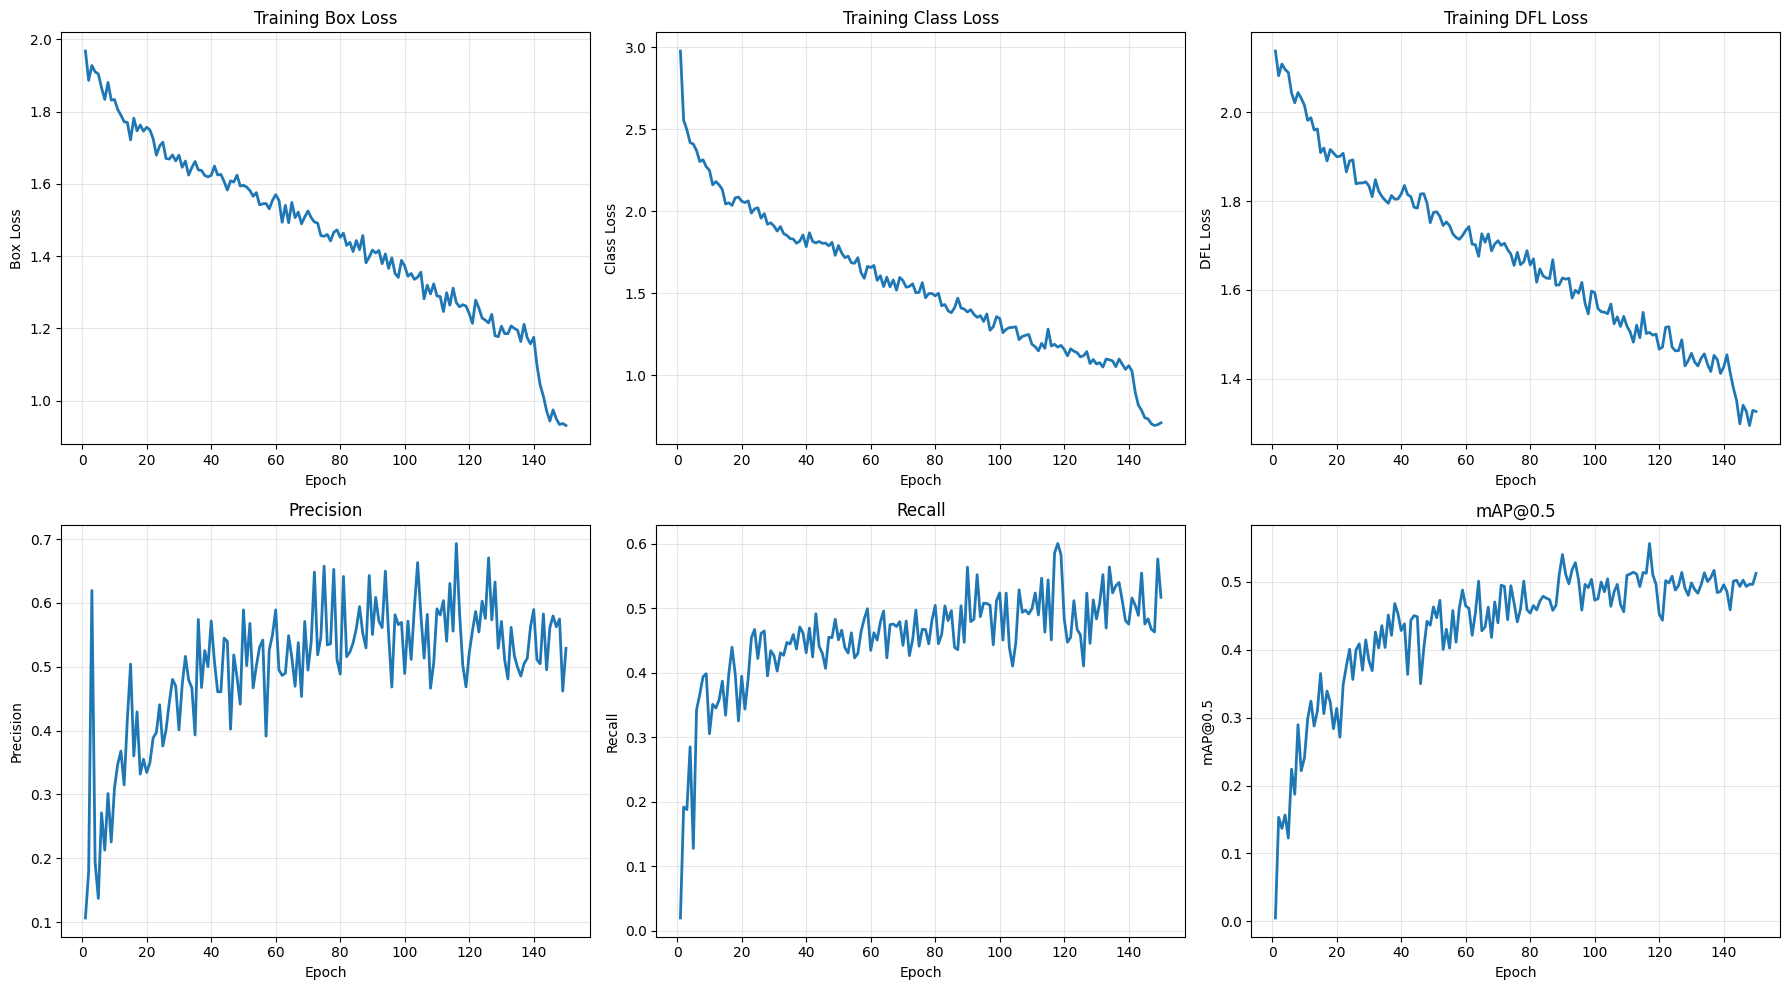


Best Training Results
mAP@0.5:  0.5561 (epoch 117)
Precision: 0.6930 (epoch 116)
Recall:    0.6005 (epoch 118)


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt


def plot_training_metrics():
    results_file = f'/content/runs/detect/{PROJECT_NAME}/{EXPERIMENT_NAME}/results.csv'

    if not os.path.exists(results_file):
        print("Results file not found!")
        return

    df = pd.read_csv(results_file)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    metrics_to_plot = [
        ('train/box_loss', 'Box Loss', 'Training Box Loss'),
        ('train/cls_loss', 'Class Loss', 'Training Class Loss'),
        ('train/dfl_loss', 'DFL Loss', 'Training DFL Loss'),
        ('metrics/precision(B)', 'Precision', 'Precision'),
        ('metrics/recall(B)', 'Recall', 'Recall'),
        ('metrics/mAP50(B)', 'mAP@0.5', 'mAP@0.5')
    ]

    for i, (metric, ylabel, title) in enumerate(metrics_to_plot):
        if metric in df.columns:
            axes[i].plot(
                df['epoch'],
                df[metric],
                linewidth=2
            )

            axes[i].set_xlabel('Epoch')
            axes[i].set_ylabel(ylabel)
            axes[i].set_title(title)
            axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Display the best results
    best_map = df['metrics/mAP50(B)'].max()
    best_map_epoch = df.loc[df['metrics/mAP50(B)'].idxmax(), 'epoch']

    best_precision = df['metrics/precision(B)'].max()
    best_precision_epoch = df.loc[df['metrics/precision(B)'].idxmax(), 'epoch']

    best_recall = df['metrics/recall(B)'].max()
    best_recall_epoch = df.loc[df['metrics/recall(B)'].idxmax(), 'epoch']

    print("\nBest Training Results")
    print(f"mAP@0.5:  {best_map:.4f} (epoch {int(best_map_epoch)})")
    print(f"Precision: {best_precision:.4f} (epoch {int(best_precision_epoch)})")
    print(f"Recall:    {best_recall:.4f} (epoch {int(best_recall_epoch)})")


plot_training_metrics()

Confusion Matrix and F1 Curve

Available plots:
✓ confusion_matrix.png
✗ F1_curve.png
✗ P_curve.png
✗ R_curve.png
✗ PR_curve.png
✓ labels.jpg

Displaying available plots:

Confusion Matrix:


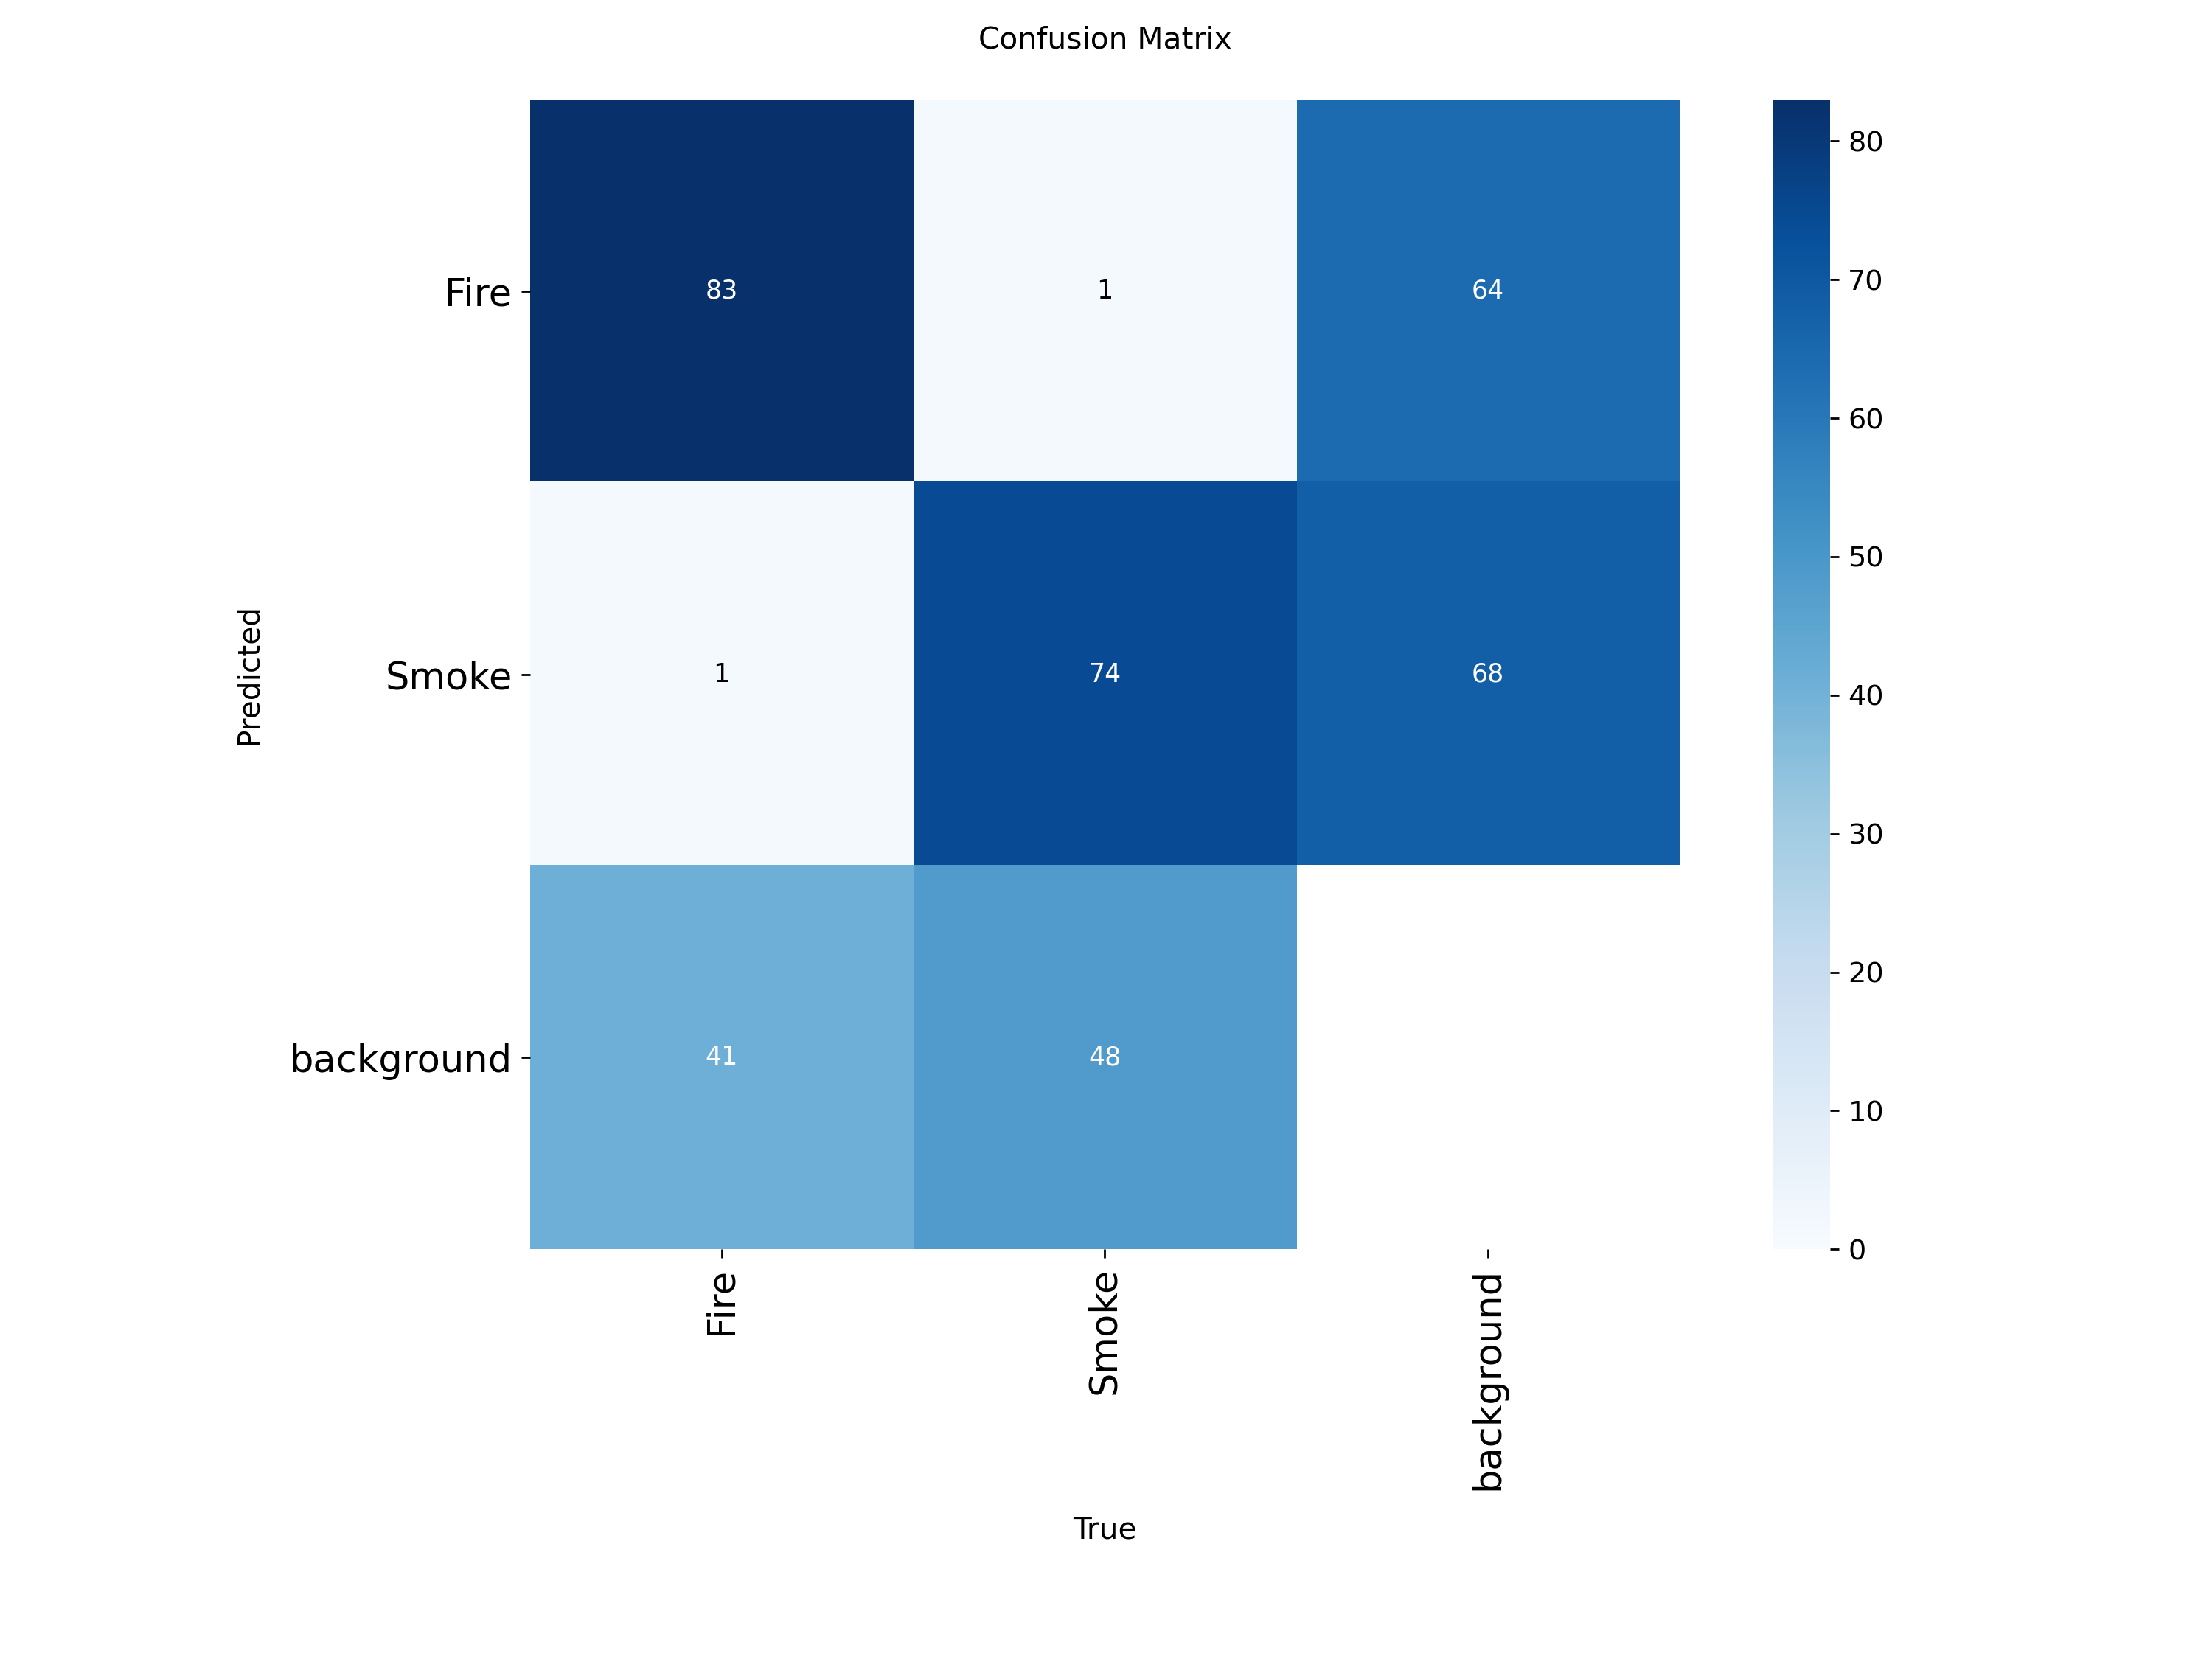


F1 curve not found

Precision-Recall curve not found

Precision curve not found

Recall curve not found


In [ ]:
from IPython.display import Image, display
import os

results_path = f'/content/runs/detect/{PROJECT_NAME}/{EXPERIMENT_NAME}'

confusion_path = os.path.join(results_path, 'confusion_matrix.png')
f1_path = os.path.join(results_path, 'F1_curve.png')

# Check for all available plots
plot_files = [
    'confusion_matrix.png',
    'F1_curve.png',
    'P_curve.png',
    'R_curve.png',
    'PR_curve.png',
    'labels.jpg'
]

print("Available plots:")

for plot in plot_files:
    full_path = os.path.join(results_path, plot)

    if os.path.exists(full_path):
        print(f"✓ {plot}")
    else:
        print(f"✗ {plot}")

print("\nDisplaying available plots:")

# Confusion Matrix
if os.path.exists(confusion_path):
    print("\nConfusion Matrix:")
    display(Image(filename=confusion_path))
else:
    print("\nConfusion matrix not found")

# F1 Curve
if os.path.exists(f1_path):
    print("\nF1 Curve:")
    display(Image(filename=f1_path))
else:
    print("\nF1 curve not found")

# Precision-Recall Curve
pr_curve_path = os.path.join(results_path, 'PR_curve.png')

if os.path.exists(pr_curve_path):
    print("\nPrecision-Recall Curve:")
    display(Image(filename=pr_curve_path))
else:
    print("\nPrecision-Recall curve not found")

# Precision Curve
p_curve_path = os.path.join(results_path, 'P_curve.png')

if os.path.exists(p_curve_path):
    print("\nPrecision Curve:")
    display(Image(filename=p_curve_path))
else:
    print("\nPrecision curve not found")

# Recall Curve
r_curve_path = os.path.join(results_path, 'R_curve.png')

if os.path.exists(r_curve_path):
    print("\nRecall Curve:")
    display(Image(filename=r_curve_path))
else:
    print("\nRecall curve not found")

In [ ]:
import shutil
import os

# Source model path
source_path = '/content/runs/detect/fire_smoke_detector/experiment_v2/weights/best.pt'

# Destination folder in Google Drive
drive_folder = '/content/drive/MyDrive/fire_smoke_detector'

# Create folder if it doesn't exist
os.makedirs(drive_folder, exist_ok=True)

# Destination path
destination_path = os.path.join(drive_folder, 'fire_smoke_best_model.pt')

# Copy the model to Google Drive
if os.path.exists(source_path):
    shutil.copy(source_path, destination_path)

    print("✓ Model saved successfully to Google Drive!")
    print(f"  Source: {source_path}")
    print(f"  Saved to: {destination_path}")
    print(f"  Size: {os.path.getsize(destination_path) / 1024 / 1024:.2f} MB")
else:
    print(f"✗ Model not found at: {source_path}")

✓ Model saved successfully to Google Drive!
  Source: /content/runs/detect/fire_smoke_detector/experiment_v2/weights/best.pt
  Saved to: /content/drive/MyDrive/fire_smoke_detector/fire_smoke_best_model.pt
  Size: 21.49 MB


Testing on 11 random images...


0: 640x640 1 Fire, 9.5ms
1: 640x640 2 Fires, 9.5ms
2: 640x640 3 Smokes, 9.5ms
3: 640x640 2 Fires, 9.5ms
4: 640x640 1 Smoke, 9.5ms
5: 640x640 (no detections), 9.5ms
6: 640x640 1 Smoke, 9.5ms
7: 640x640 1 Fire, 9.5ms
8: 640x640 1 Fire, 9.5ms
9: 640x640 1 Fire, 9.5ms
10: 640x640 1 Fire, 9.5ms
Speed: 3.0ms preprocess, 9.5ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/drive/MyDrive/fire_smoke_detector/test_predictions

Test detection completed!
Results saved to: /content/drive/MyDrive/fire_smoke_detector/test_predictions

Displaying 22 detected images:



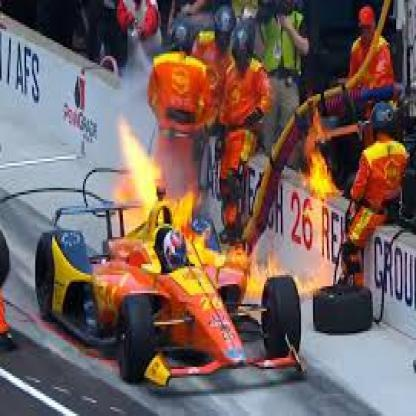

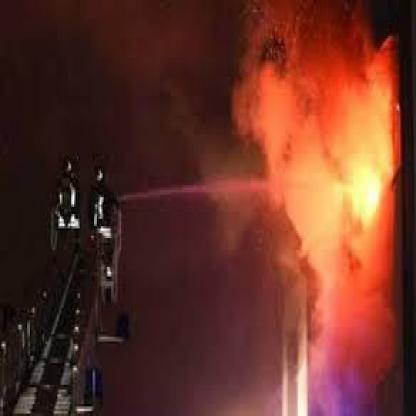

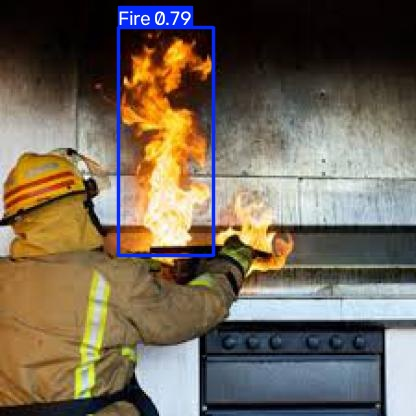

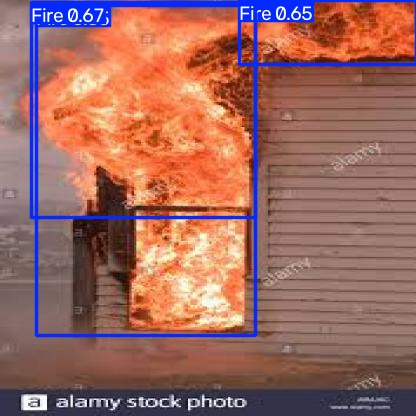

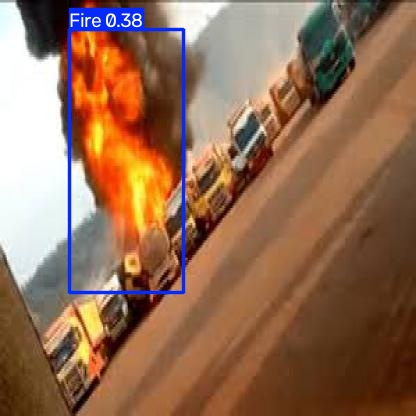

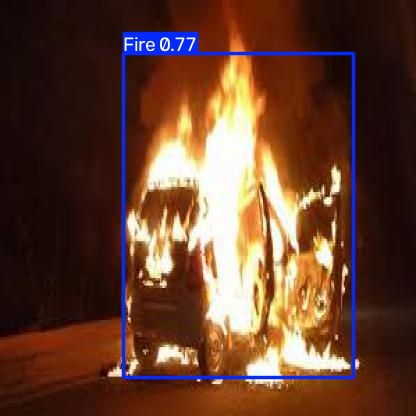

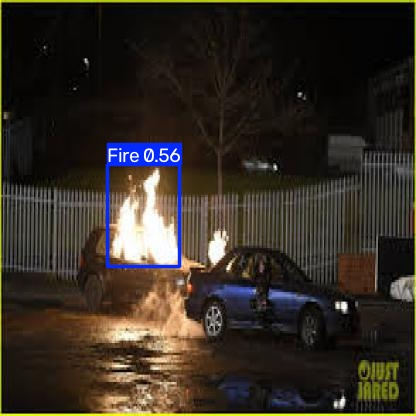

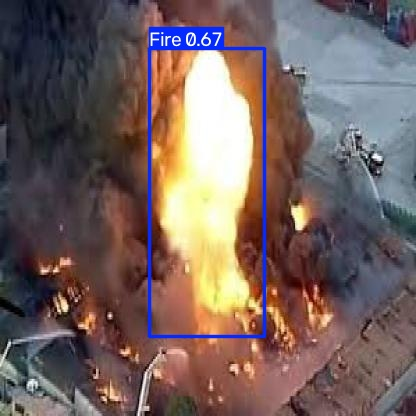

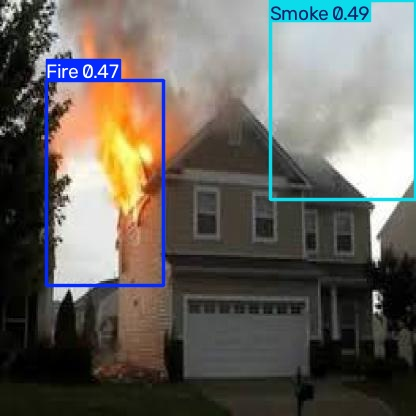

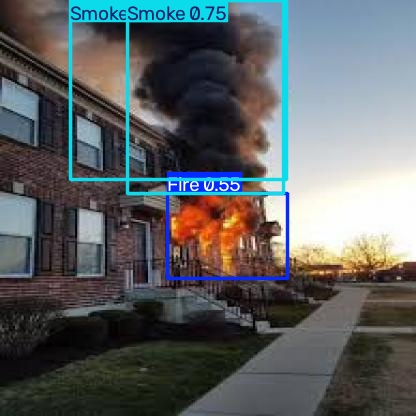

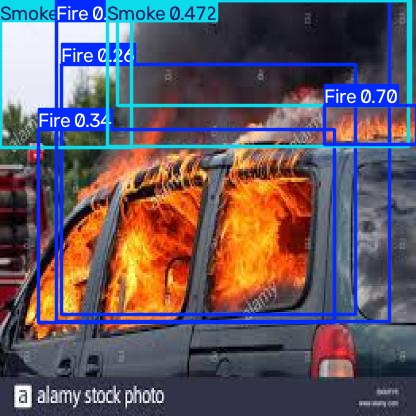

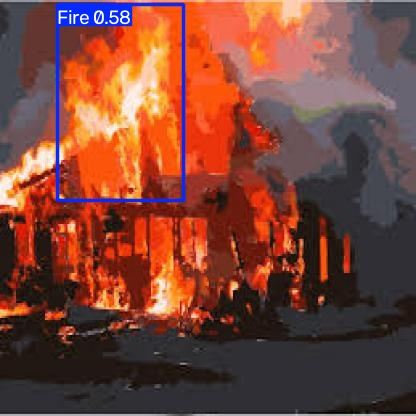

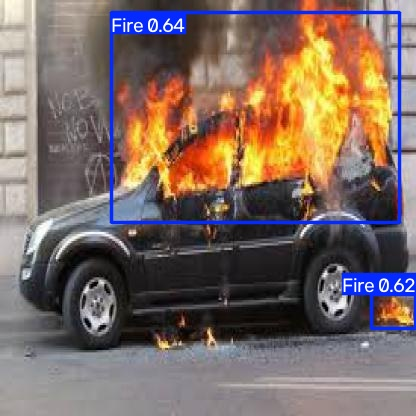

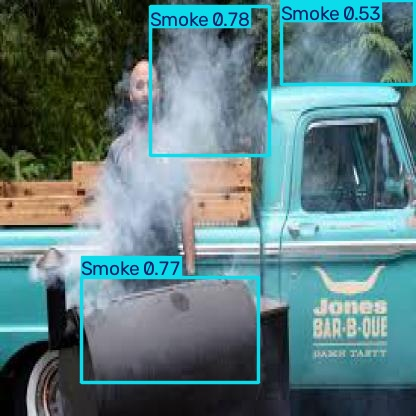

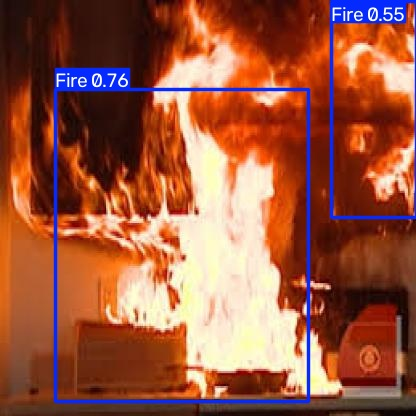

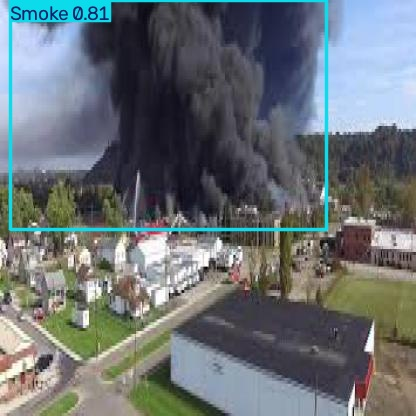

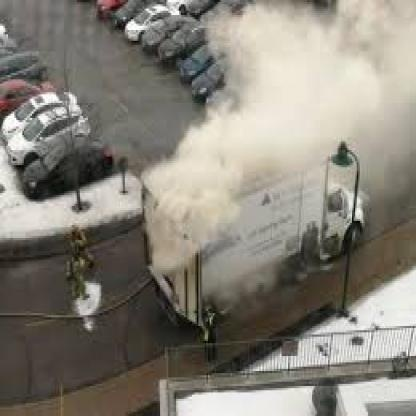

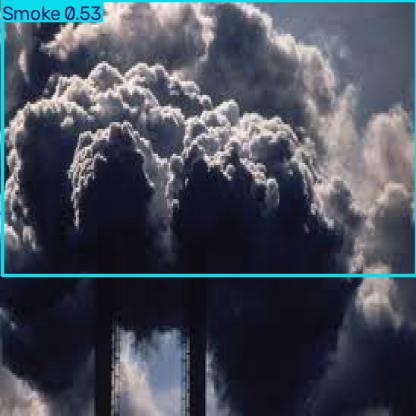

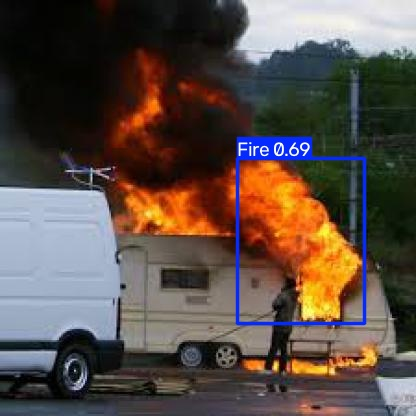

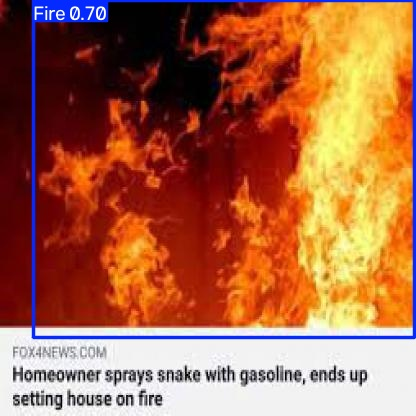

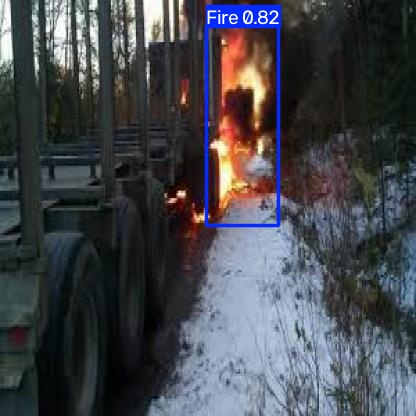

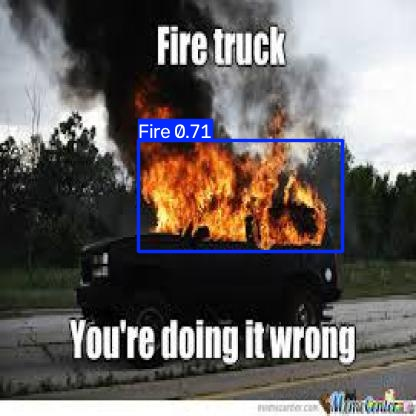

In [ ]:
from ultralytics import YOLO
import os
import random
import glob
from IPython.display import Image, display

# Load your best trained model
model = YOLO('/content/drive/MyDrive/fire_smoke_detector/fire_smoke_best_model.pt')

# Test images folder
test_images = '/content/drive/MyDrive/Dataset/test/images'

# Output folder
output_folder = '/content/drive/MyDrive/fire_smoke_detector/test_predictions'
os.makedirs(output_folder, exist_ok=True)

# Get all test images
image_files = glob.glob(os.path.join(test_images, '*'))

# Select 11 random images
random.seed(42)
selected_images = random.sample(image_files, min(11, len(image_files)))

print(f"Testing on {len(selected_images)} random images...\n")

# Run detection only on selected images
results = model.predict(
    source=selected_images,
    conf=0.5,          # raise from 0.25 → drops weak/unsure boxes
    iou=0.3,            # tighter NMS → merges overlapping duplicate boxes
    agnostic_nms=True,  # suppress overlaps even across classes
    imgsz=640,
    save=True,
    project='/content/drive/MyDrive/fire_smoke_detector',
    name='test_predictions',
    exist_ok=True
)

print("\nTest detection completed!")
print(f"Results saved to: {output_folder}")

# Display the results
prediction_images = glob.glob(os.path.join(output_folder, '*'))

print(f"\nDisplaying {len(prediction_images)} detected images:\n")

for img in prediction_images:
    display(Image(filename=img, width=700))

Saving images (1).jpg to images (1).jpg

image 1/1 /content/images (1).jpg: 640x640 1 Fire, 2 Smokes, 16.2ms
Speed: 2.5ms preprocess, 16.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Detection completed!
Result saved at: /content/runs/detect/predict/images (1).jpg


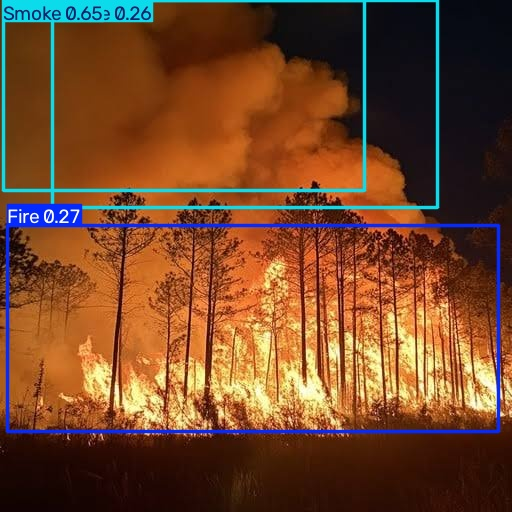

In [ ]:
from ultralytics import YOLO
from google.colab import files
from IPython.display import Image, display
import os

# Load your trained model
model = YOLO('/content/drive/MyDrive/fire_smoke_detector/fire_smoke_best_model.pt')

# Upload an image
uploaded = files.upload()

# Get uploaded image name
image_path = list(uploaded.keys())[0]

# Run detection
results = model.predict(
    source=image_path,
    conf=0.25,
    imgsz=640,
    save=True
)

# Get the saved prediction path
result_path = results[0].save_dir
output_image = os.path.join(result_path, image_path)

print("Detection completed!")
print(f"Result saved at: {output_image}")

# Display detected image
display(Image(filename=output_image, width=800))

In [ ]:
import os
from PIL import Image

night_count = 0
day_count = 0

for fname in os.listdir(train_img_path):
    img_path = os.path.join(train_img_path, fname)
    try:
        img = Image.open(img_path).convert('L')  # grayscale
        avg_brightness = sum(img.getdata()) / (img.width * img.height)
        if avg_brightness < 60:  # rough threshold, adjust after eyeballing a few
            night_count += 1
        else:
            day_count += 1
    except:
        continue

print(f"Likely night/dark images: {night_count}")
print(f"Likely day/bright images: {day_count}")


Likely night/dark images: 66
Likely day/bright images: 531


In [1]:
import cv2
import os
import numpy as np

def darken_image(img, factor=0.35):
    return (img.astype(np.float32) * factor).clip(0, 255).astype(np.uint8)

src_dir = train_img_path
dst_img_dir = os.path.join(dataset_path, "train", "images")  # save alongside originals
dst_lbl_dir = os.path.join(dataset_path, "train", "labels")

count = 0
for fname in os.listdir(src_dir):
    if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue
    img_path = os.path.join(src_dir, fname)
    label_path = os.path.join(train_lbl_path, os.path.splitext(fname)[0] + '.txt')
    if not os.path.exists(label_path):
        continue

    img = cv2.imread(img_path)
    dark_img = darken_image(img, factor=np.random.uniform(0.25, 0.45))

    new_name = f"dark_{fname}"
    cv2.imwrite(os.path.join(dst_img_dir, new_name), dark_img)

    # copy label unchanged — bounding boxes stay the same, only pixels changed
    with open(label_path, 'r') as f:
        label_content = f.read()
    with open(os.path.join(dst_lbl_dir, f"dark_{os.path.splitext(fname)[0]}.txt"), 'w') as f:
        f.write(label_content)

    count += 1

print(f"Created {count} synthetic night-augmented images")

NameError: name 'train_img_path' is not defined